# Análisis Exploratorio de Datos (EDA) - Incontinencia Urinaria
**Autora:** Isabel (Scrum Master - Equipo 3)
**Fecha:** 16/03/2026

## 1. Carga y Validación de Datos
En este primer paso, conectamos con el dataset original proporcionado por Iris en la carpeta `data/raw/`. 
Nuestro objetivo es verificar que las dimensiones coincidan con la documentación técnica (9.074 registros).

In [1]:
import pandas as pd
import os

# Definimos la ruta relativa al archivo CSV que subió Iris
# Estamos en notebooks/modeling/, así que subimos dos niveles para llegar a data/raw/
ruta_datos = os.path.join("..", "..", "data", "raw", "nhanes_ui_women.csv")

try:
    df = pd.read_csv(ruta_datos)
    print("✅ ¡Datos cargados con éxito!")
    print(f"📊 Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas")
    
    # Mostramos las primeras 5 filas para verificar el contenido
    display(df.head())
except FileNotFoundError:
    print("❌ Error: No se encuentra el archivo en la ruta especificada.")
    print(f"Buscando en: {os.path.abspath(ruta_datos)}")
except Exception as e:
    print(f"❌ Ha ocurrido un error inesperado: {e}")

✅ ¡Datos cargados con éxito!
📊 Dimensiones del dataset: 9074 filas y 27 columnas


,id_participante,ciclo_nhanes,peso_encuesta,edad_anios,etnia,pais_nacimiento,imc,dx_hipertension,medicacion_hta_cicloP,medicacion_hta_cicloL,...,ui_cantidad,ui_esfuerzo_presente,ui_esfuerzo_frecuencia,ui_urgencia_presente,ui_urgencia_frecuencia,ui_otro_tipo_presente,ui_molestia_percibida,ui_impacto_actividades,target_tiene_ui,target_tipo_ui
0,109266.0,2017-March2020,NaN,29.0,5.0,2.0,37.8,2.0,NaN,NaN,...,NaN,2.0,NaN,2.0,NaN,2.0,NaN,NaN,0,none
1,109267.0,2017-March2020,NaN,21.0,2.0,2.0,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,none
2,109284.0,2017-March2020,NaN,44.0,1.0,2.0,39.1,2.0,NaN,NaN,...,1.0,1.0,1.0,2.0,NaN,2.0,2.0,2.0,1,stress
3,109286.0,2017-March2020,NaN,33.0,5.0,2.0,28.9,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,none
4,109290.0,2017-March2020,NaN,68.0,4.0,1.0,28.1,1.0,1.0,NaN,...,2.0,2.0,NaN,1.0,1.0,2.0,2.0,1.0,1,urge


In [2]:
# Inspección de tipos de datos y valores nulos oficiales de Pandas
print("📋 Información general del DataFrame:")
display(df.info())

print("\n🔍 Recuento de valores nulos directos (NaN):")
print(df.isnull().sum())

📋 Información general del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 9074 entries, 0 to 9073
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_participante            9074 non-null   float64
 1   ciclo_nhanes               9074 non-null   str    
 2   peso_encuesta              4321 non-null   float64
 3   edad_anios                 9074 non-null   float64
 4   etnia                      9074 non-null   float64
 5   pais_nacimiento            9067 non-null   float64
 6   imc                        7620 non-null   float64
 7   dx_hipertension            9074 non-null   float64
 8   medicacion_hta_cicloP      1694 non-null   float64
 9   medicacion_hta_cicloL      1599 non-null   float64
 10  dx_diabetes                9074 non-null   float64
 11  dx_cancer                  9074 non-null   float64
 12  dx_artritis                9074 non-null   float64
 13  fumadora_alguna_vez   

None


🔍 Recuento de valores nulos directos (NaN):
id_participante                 0
ciclo_nhanes                    0
peso_encuesta                4753
edad_anios                      0
etnia                           0
pais_nacimiento                 7
imc                          1454
dx_hipertension                 0
medicacion_hta_cicloP        7380
medicacion_hta_cicloL        7475
dx_diabetes                     0
dx_cancer                       0
dx_artritis                     0
fumadora_alguna_vez             6
actividad_fisica_vigorosa    4321
nivel_pobreza_familiar        905
ui_frecuencia                2180
ui_cantidad                  5522
ui_esfuerzo_presente         2185
ui_esfuerzo_frecuencia       7339
ui_urgencia_presente         2190
ui_urgencia_frecuencia       7724
ui_otro_tipo_presente        5020
ui_molestia_percibida        6706
ui_impacto_actividades       4861
target_tiene_ui                 0
target_tipo_ui                  0
dtype: int64


### 1.1 Identificación de Nulos (NaN)
Hemos detectado una gran cantidad de valores nulos (`NaN`) en columnas específicas relacionadas con la frecuencia de los síntomas y medicación. Esto sugiere que el dataset contiene muchas preguntas condicionadas.

In [3]:
# Buscamos los códigos 7, 9 y 99 que Iris mencionó como nulos camuflados
codigos_nulos = [7, 9, 99]
print("⚠️ Detección de códigos de 'No sabe/No contesta' (7, 9, 99):")

for col in df.columns:
    conteo = df[df[col].isin(codigos_nulos)][col].count()
    if conteo > 0:
        print(f"- Columna '{col}': {conteo} registros con códigos 7, 9 o 99")

⚠️ Detección de códigos de 'No sabe/No contesta' (7, 9, 99):
- Columna 'pais_nacimiento': 1 registros con códigos 7, 9 o 99
- Columna 'dx_hipertension': 10 registros con códigos 7, 9 o 99
- Columna 'medicacion_hta_cicloL': 2 registros con códigos 7, 9 o 99
- Columna 'dx_diabetes': 5 registros con códigos 7, 9 o 99
- Columna 'dx_cancer': 8 registros con códigos 7, 9 o 99
- Columna 'dx_artritis': 27 registros con códigos 7, 9 o 99
- Columna 'fumadora_alguna_vez': 8 registros con códigos 7, 9 o 99
- Columna 'nivel_pobreza_familiar': 281 registros con códigos 7, 9 o 99
- Columna 'ui_frecuencia': 7 registros con códigos 7, 9 o 99
- Columna 'ui_cantidad': 3 registros con códigos 7, 9 o 99
- Columna 'ui_esfuerzo_presente': 7 registros con códigos 7, 9 o 99
- Columna 'ui_esfuerzo_frecuencia': 1 registros con códigos 7, 9 o 99
- Columna 'ui_urgencia_presente': 8 registros con códigos 7, 9 o 99
- Columna 'ui_urgencia_frecuencia': 1 registros con códigos 7, 9 o 99
- Columna 'ui_otro_tipo_presente

### 1.2 Tratamiento de códigos de error (7, 9, 99)
Tras la inspección, se confirma la presencia de códigos de respuesta nula camuflados como valores numéricos. 
Procederemos a su estandarización a `NaN` para evitar distorsiones en el análisis estadístico y en el entrenamiento del modelo.

In [4]:
import numpy as np

# Creamos una copia de seguridad antes de limpiar
df_clean = df.copy()

# Reemplazamos los códigos 7, 9 y 99 por NaN (Nulo real)
# Nota: Solo en columnas donde estos valores no tengan sentido real
for col in df_clean.columns:
    df_clean[col] = df_clean[col].replace([7, 9, 99], np.nan)

print("✅ Estandarización completada.")
print(f"Nulos totales tras limpieza en 'nivel_pobreza_familiar': {df_clean['nivel_pobreza_familiar'].isnull().sum()}")

✅ Estandarización completada.
Nulos totales tras limpieza en 'nivel_pobreza_familiar': 1186


## 2. Análisis de la Variable Objetivo (Target)
Exploramos la distribución de `target_tiene_ui` para entender la prevalencia de la condición en nuestra muestra de mujeres.

C:\Users\Coder\AppData\Local\Temp\ipykernel_22796\2087162517.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='target_tiene_ui', palette='viridis')


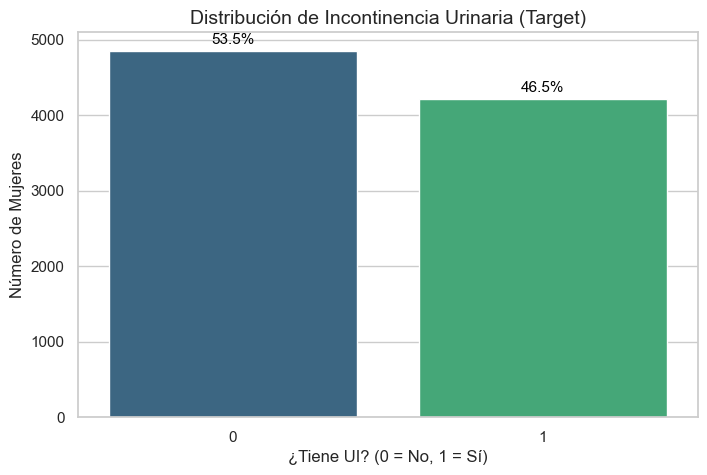

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Gráfico de conteo
ax = sns.countplot(data=df_clean, x='target_tiene_ui', palette='viridis')

# Añadir títulos y etiquetas
plt.title('Distribución de Incontinencia Urinaria (Target)', fontsize=14)
plt.xlabel('¿Tiene UI? (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Número de Mujeres', fontsize=12)

# Añadir porcentajes sobre las barras
total = len(df_clean)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

## 3. Relación entre Edad e Incontinencia
Analizamos si la distribución de edad varía significativamente entre las mujeres que presentan la condición y las que no.

C:\Users\Coder\AppData\Local\Temp\ipykernel_22796\2549449109.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='target_tiene_ui', y='edad_anios', palette='magma')


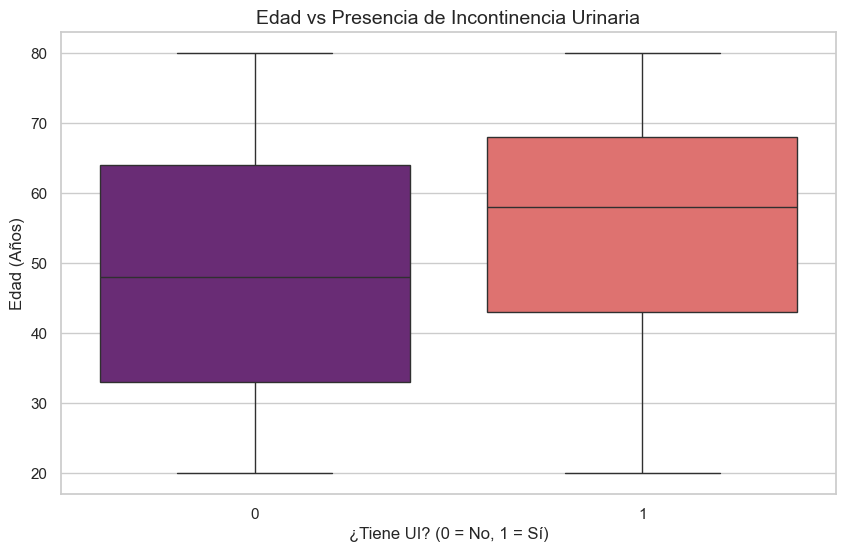

In [6]:
plt.figure(figsize=(10, 6))

# Gráfico de cajas (Boxplot) para ver la dispersión
sns.boxplot(data=df_clean, x='target_tiene_ui', y='edad_anios', palette='magma')

plt.title('Edad vs Presencia de Incontinencia Urinaria', fontsize=14)
plt.xlabel('¿Tiene UI? (0 = No, 1 = Sí)', fontsize=12)
plt.ylabel('Edad (Años)', fontsize=12)
plt.show()

## 4. Conclusiones del Día 1
* Se ha estandarizado el dataset eliminando códigos de error (7, 9, 99).
* El dataset está balanceado (46.5% de positivos).
* Se confirma una correlación visual clara entre la edad avanzada y la presencia de UI.